# Packages

https://unit8co.github.io/darts/examples/13-TFT-examples.html

In [36]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split,cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score


In [37]:
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

# Feature Engineering

In [38]:
df.head(1)

,month_date_yyyymm,county_fips,county_name_x,median_listing_price_x,median_listing_price_mm_x,median_listing_price_yy_x,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market_x,...,U.S. 30 year FRM,30 year fees & points,U.S. 15 year FRM,15 year fees & points,U.S. 5/1 ARM,5/1 year fees & points,U.S. 5/1 ARM margin,30 year FRM / 5/1 ARM spread,date_y,highest_category
0,2016-07-01,1001,"autauga, al",186400.0,NaN,NaN,295,NaN,NaN,72.0,...,3.44,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69,NaN,NaN


In [39]:
# Cleaning columns

# Dropping lags, dupicate columns
df = df[['month_date_yyyymm'
                      , 'county_fips'
                      , 'county_name_x'
                      , 'median_listing_price_x' #taking median to control for outliers
                      , 'active_listing_count'
                      , 'median_days_on_market_x'
                      , 'new_listing_count'
                      , 'price_increased_count'
                      , 'price_increased_share'
                      , 'price_reduced_count'
                      , 'price_reduced_share'
                      , 'pending_listing_count'
                      #, 'median_listing_price_per_square_foot' #leaking target
                      , 'median_square_feet'
                      #, 'average_listing_price' #leaking target
                      , 'total_listing_count'
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

# Feature analysis

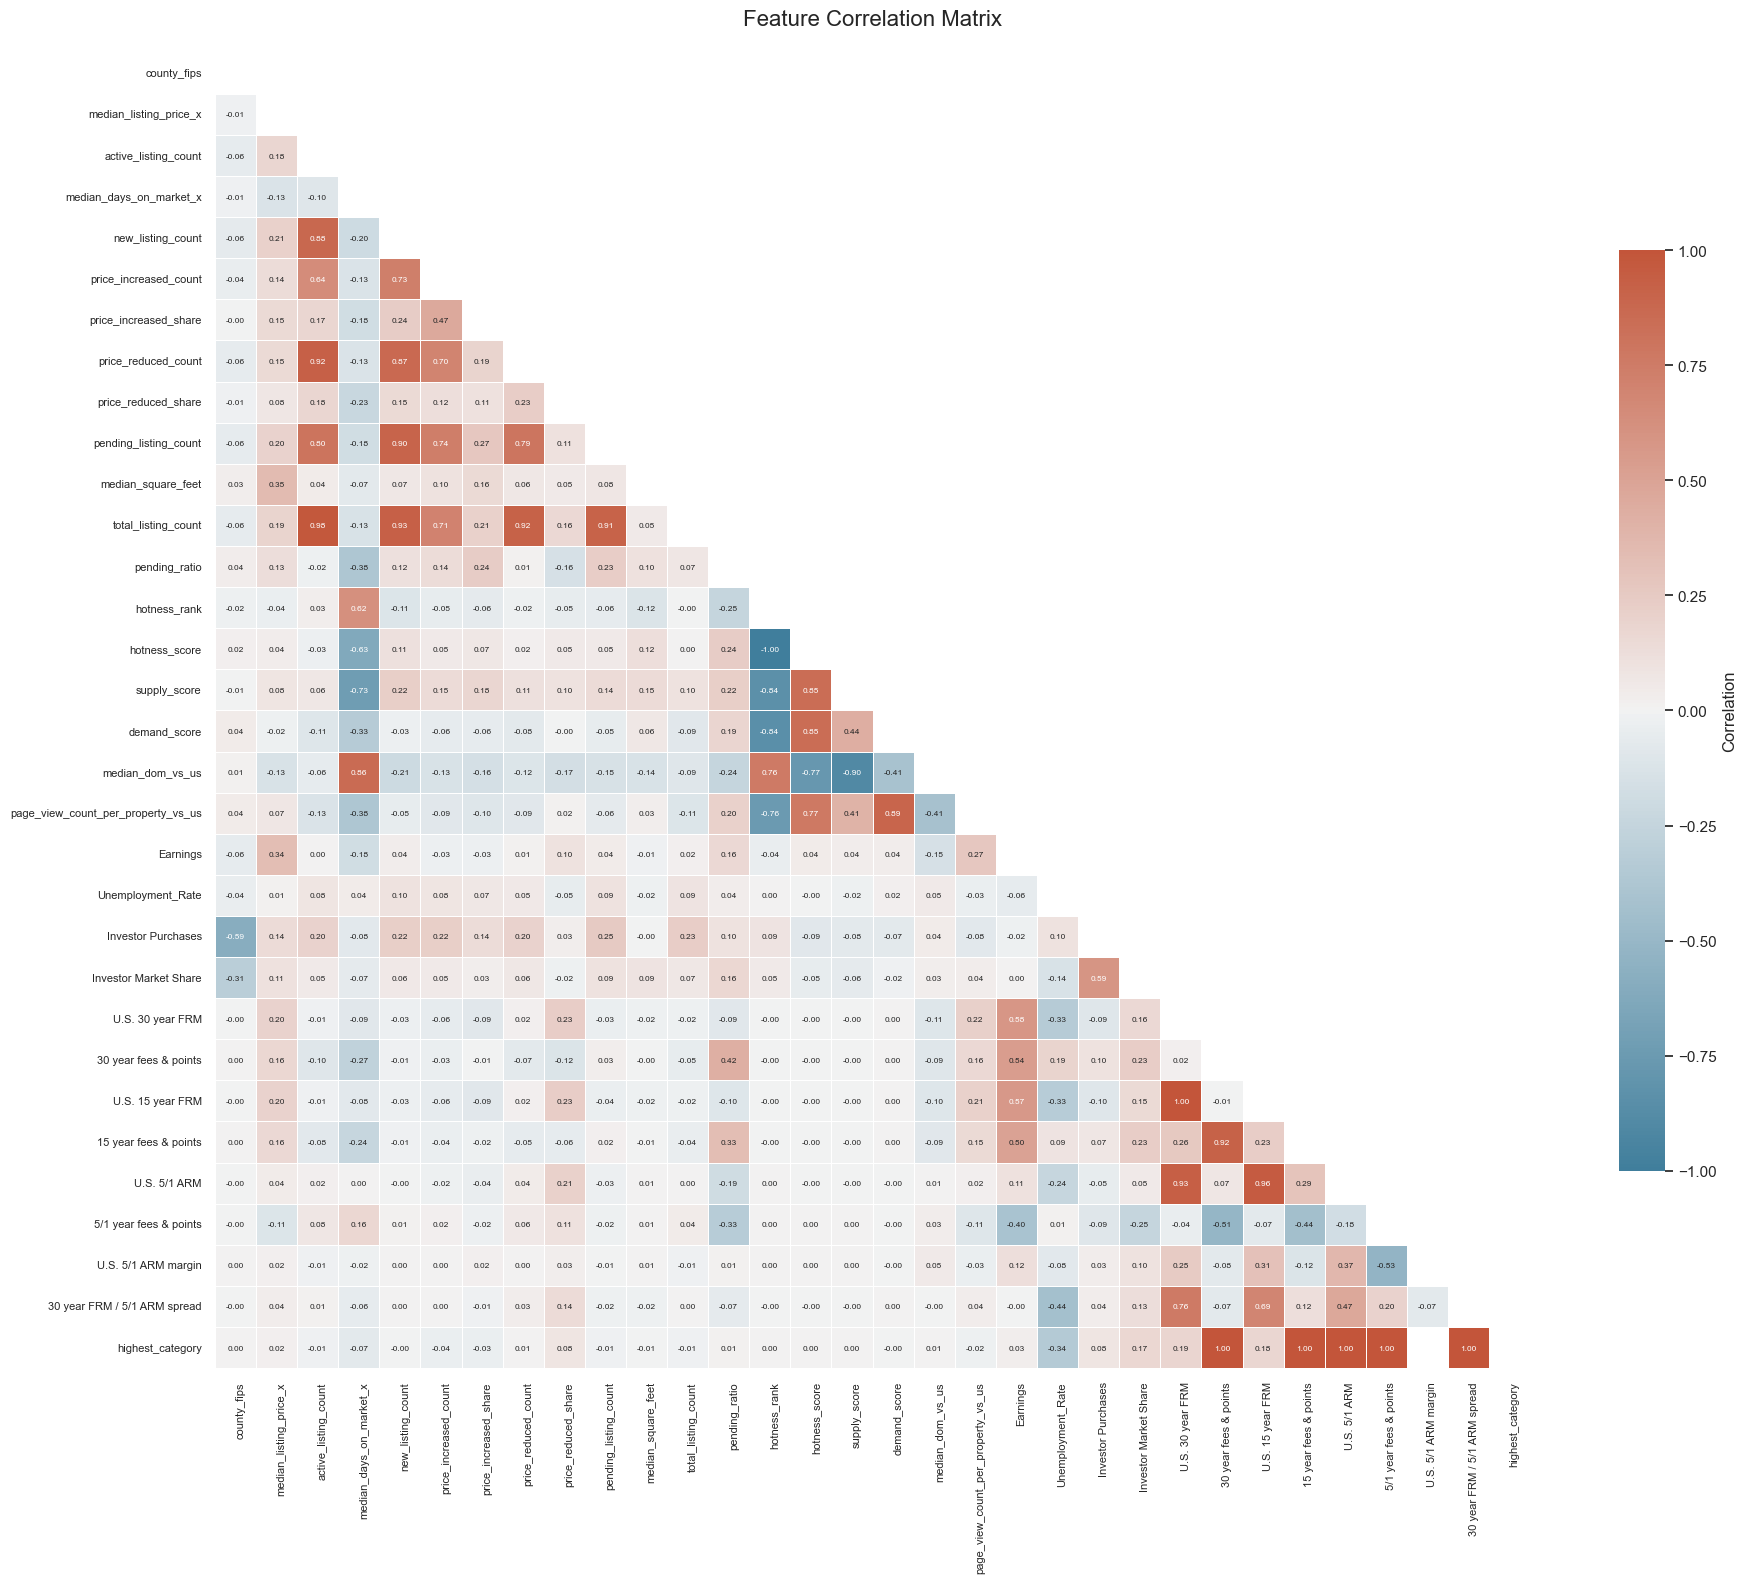

In [40]:
corr = df.select_dtypes(include=[np.number]).corr()

# Cluster the correlation matrix for better grouping
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(20, 16))

# Mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlation"},
    ax=ax
)

ax.set_title("Feature Correlation Matrix", fontsize=16, pad=20)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

- Total listing count and total price reduced are highly correlated with median list price.
- Morgage data seem off, some have correlation of 1 for features un related like highest category.
- Some multi coleanarity. Hotness score and hotness rank.

In [41]:
df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
                 ,'highest_category' #Florida only, dropping for now
                 ,'U.S. 15 year FRM' # dropping, highly correlated with 30 year 
                 ,'county_name_x' #county fips is numeric version
                 ,'city' # dupicative with fips
                 #,'state' # dupicative with fips
                 ], inplace=True)

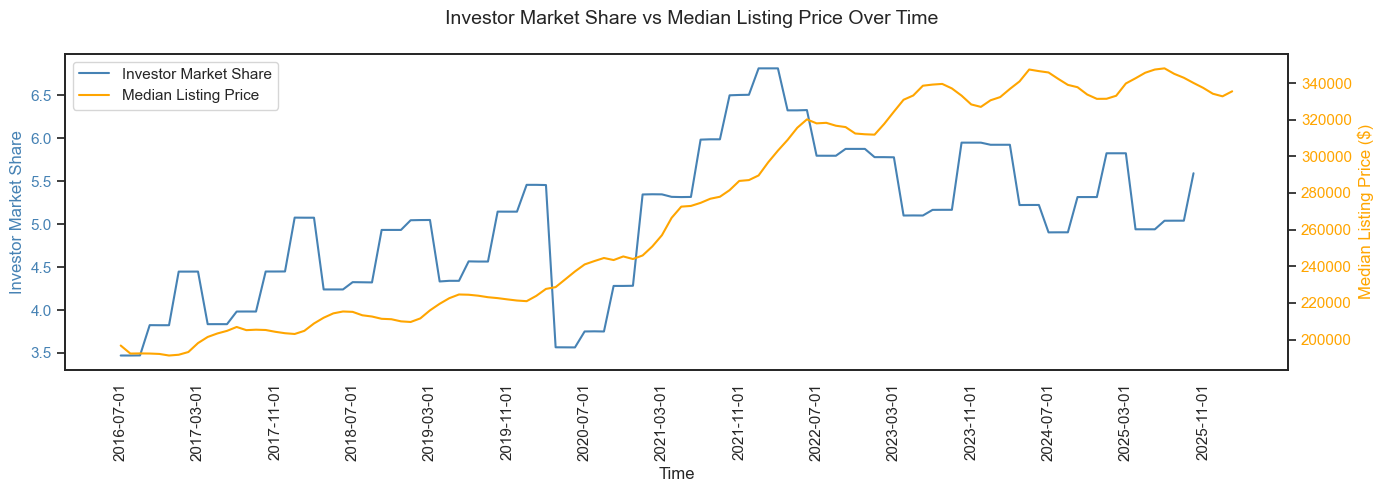

In [42]:
df_plot = (
    df[['month_date_yyyymm', 'Investor Market Share', 'median_listing_price_x']]
    .groupby('month_date_yyyymm')[['Investor Market Share', 'median_listing_price_x']]
    .mean()
    .sort_index()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df_plot['month_date_yyyymm'], df_plot['Investor Market Share'], color='steelblue', label='Investor Market Share')
ax1.set_xlabel('Time')
ax1.set_ylabel('Investor Market Share', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.xaxis.set_major_locator(plt.MaxNLocator(20))
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(df_plot['month_date_yyyymm'], df_plot['median_listing_price_x'], color='orange', label='Median Listing Price')
ax2.set_ylabel('Median Listing Price ($)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.suptitle('Investor Market Share vs Median Listing Price Over Time', fontsize=14)
plt.tight_layout()
plt.show()

# XGB

### Pipeline

In [46]:

# ---------------------------
# 1. Define target + features
# ---------------------------

target_col = "median_listing_price_x"

df_clean = df.dropna(subset=[target_col])
df_clean['month_date_yyyymm'] = df_clean['month_date_yyyymm'].astype(str).str.replace('-', '', regex=False)

df_clean = df_clean[df_clean['month_date_yyyymm']>='202401']
#df_clean = df_clean[df_clean['state']=='fl']
df_clean.drop(columns=['state'], inplace=True)

# Sort before creating lags
df_clean = df_clean.sort_values(["county_fips", "month_date_yyyymm"])

# Create lag and rolling features BEFORE defining X so they are seen at fit time
for lag in [1, 2, 3, 6, 12]:
    df_clean[f"lag_{lag}"] = df_clean.groupby("county_fips")[target_col].shift(lag)

df_clean["price_roll_3"] = df_clean.groupby("county_fips")[target_col].transform(
    lambda s: s.shift(1).rolling(3).mean()
)
df_clean["price_roll_6"] = df_clean.groupby("county_fips")[target_col].transform(
    lambda s: s.shift(1).rolling(6).mean()
)
df_clean["price_roll_12"] = df_clean.groupby("county_fips")[target_col].transform(
    lambda s: s.shift(1).rolling(12).mean()
)

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# ---------------------------
# 2. Train/Test Split (TimeSeriesSplit — last fold used as holdout)
# ---------------------------
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5)

# Use the last split as train/test
for train_idx, test_idx in tss.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    

# ---------------------------
# 3. Pipeline
# ---------------------------
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # Remove low-variance features
    ("variance", VarianceThreshold(threshold=0.01)),
    # Optional for RF/XGB?(confirm), but keeps things consistent
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
    n_estimators=500,
    max_depth=4, # reduced from 8 to control overfitting
    learning_rate=0.01,
    device="cuda",  # GPU enabled
    random_state=1,
    enable_categorical=True,
    reg_alpha=0.1 # L1 regularization
))
])

#grid search
# Fitting 5 folds for each of 27 candidates, totalling 135 fits
# Best params: {'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 500}
# Best CV RMSE: 83586.17
# Test RMSE: 63310.51
# Test R²:   0.9275

# ---------------------------
# 4. Train
# ---------------------------
pipeline.fit(X_train, y_train)

# ---------------------------
# 5. Predict + Evaluate
# ---------------------------
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


RMSE: 80326.61
R²: 0.8669


In [47]:
# Proper naive baseline
y_pred = y_test.copy()

y_pred.iloc[0] = y_train.iloc[-1]
y_pred.iloc[1:] = y_test.iloc[:-1].values

# Align
y_test, y_pred = y_test.align(y_pred, join="inner")

from sklearn.metrics import r2_score
print("Naive R2:", r2_score(y_test, y_pred))

Naive R2: 0.9108256715854085


In [48]:
# ---------------------------
# Recursive forecast using the trained pipeline
# ---------------------------
df_full = df_clean.dropna(subset=[target_col]).copy()
df_full['month_date_yyyymm'] = df_full['month_date_yyyymm'].astype(str).str.replace('-', '', regex=False)

last_date = pd.to_datetime(df_full['month_date_yyyymm'].astype(str), format='%Y%m%d').max()
latest_rows = df_full.loc[df_full.groupby('county_fips')['month_date_yyyymm'].idxmax()].copy()

# Initialise lag/rolling columns
for lag in [1, 2, 3, 6, 12]:
    latest_rows[f'lag_{lag}'] = np.nan
for col in ['price_roll_3', 'price_roll_6', 'price_roll_12']:
    latest_rows[col] = np.nan

# Build per-county price history for recursive updates
county_history = {}
for fips in df_full['county_fips'].unique():
    county_data = df_full[df_full['county_fips'] == fips].sort_values('month_date_yyyymm')
    county_history[fips] = list(county_data[target_col].values)

horizon = 18  # number of months to forecast
forecast_records = []

for step in range(horizon):
    future_date = last_date + pd.DateOffset(months=step + 1)
    future_rows = latest_rows.copy()
    future_rows['month_date_yyyymm'] = int(future_date.strftime('%Y%m%d'))

    for fips in future_rows['county_fips'].unique():
        mask = future_rows['county_fips'] == fips
        hist = county_history[fips]
        for lag in [1, 2, 3, 6, 12]:
            future_rows.loc[mask, f'lag_{lag}'] = hist[-lag] if len(hist) >= lag else np.nan
        for window, col in [(3, 'price_roll_3'), (6, 'price_roll_6'), (12, 'price_roll_12')]:
            future_rows.loc[mask, col] = np.mean(hist[-window:]) if len(hist) >= window else np.nan

    X_future = future_rows.drop(columns=[target_col])
    preds = pipeline.predict(X_future)

    for fips, pred in zip(future_rows['county_fips'].values, preds):
        county_history[fips].append(pred)
        forecast_records.append({
            'forecast_date': future_date,
            'county_fips': fips,
            'forecasted_median_listing_price': pred
        })

df_forecast = pd.DataFrame(forecast_records)
df_forecast['forecast_date'] = pd.to_datetime(df_forecast['forecast_date'])
df_forecast = df_forecast.sort_values(['county_fips', 'forecast_date']).reset_index(drop=True)

print(f"Forecast shape: {df_forecast.shape}")
df_forecast.head(10)

Forecast shape: (56340, 3)


,forecast_date,county_fips,forecasted_median_listing_price
0,2026-03-01,1001,328632.46875
1,2026-04-01,1001,333527.21875
2,2026-05-01,1001,336271.43750
3,2026-06-01,1001,341770.90625
4,2026-07-01,1001,344547.71875
5,2026-08-01,1001,347506.78125
6,2026-09-01,1001,349377.96875
7,2026-10-01,1001,352639.93750
8,2026-11-01,1001,358337.09375
9,2026-12-01,1001,359771.00000


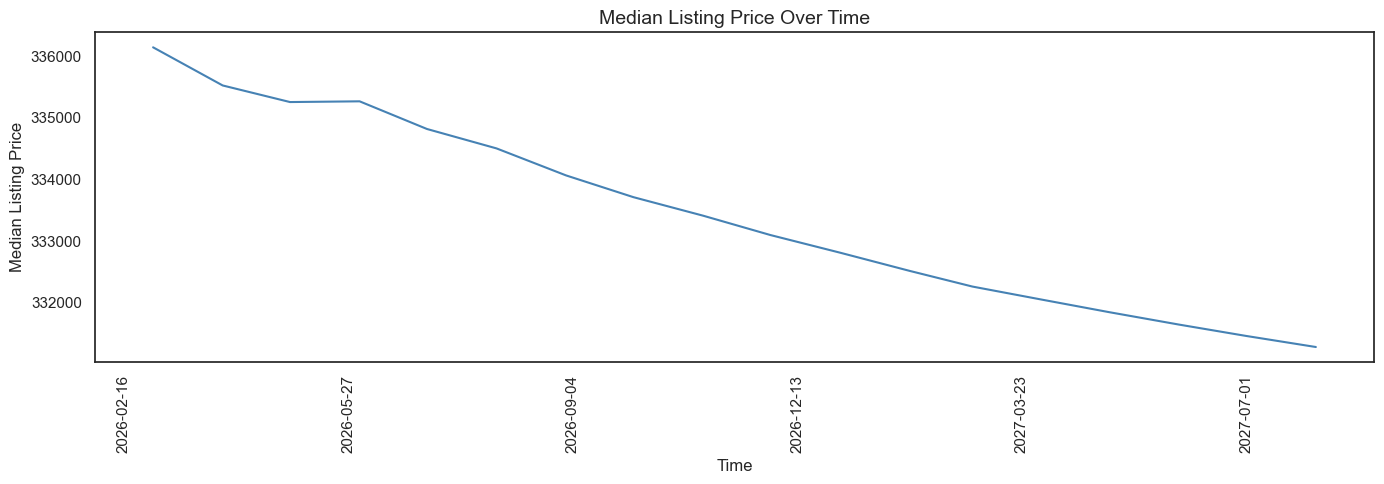

In [49]:
df_plot = df_forecast.groupby('forecast_date')[['forecasted_median_listing_price']].mean().reset_index().sort_values('forecast_date')

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=df_plot, x='forecast_date', y='forecasted_median_listing_price', ax=ax, color='steelblue')
ax.set_title('Median Listing Price Over Time', fontsize=14)
ax.set_xlabel('Time')
ax.set_ylabel('Median Listing Price')
ax.xaxis.set_major_locator(plt.MaxNLocator(7))
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

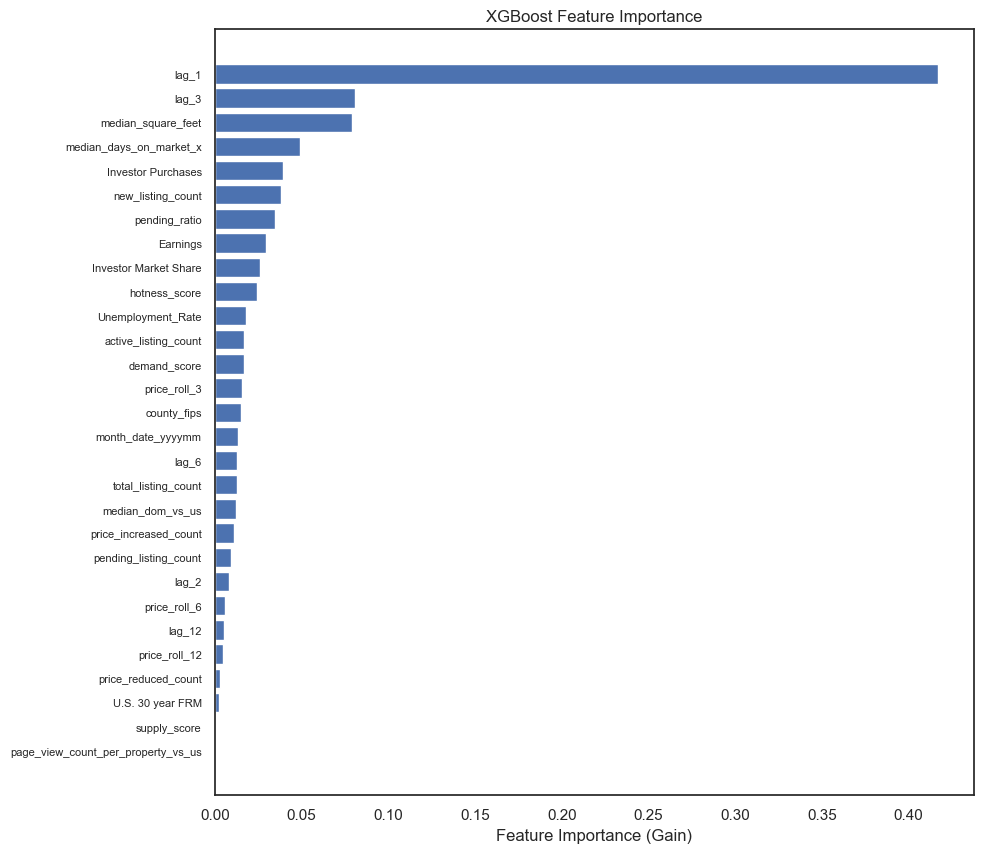

In [50]:
# Feature importance from XGB model
model = pipeline.named_steps["model"]
feature_names = pipeline.named_steps["variance"].get_feature_names_out(
    pipeline.named_steps["imputer"].get_feature_names_out()
)

importances = model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.3)))
ax.barh(range(len(sorted_idx)), importances[sorted_idx])
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(feature_names[sorted_idx], fontsize=8)
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

### Cross Validation

In [51]:
# Define CV strategy
from sklearn.model_selection import TimeSeriesSplit

kf = TimeSeriesSplit(n_splits=5)

# RMSE (negative because sklearn maximizes scores)
rmse_scores = cross_val_score(
    pipeline,
    pd.concat([X_train, X_test]),
    pd.concat([y_train, y_test]),
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

# R² scores
r2_scores = cross_val_score(
    pipeline,
    pd.concat([X_train, X_test]),
    pd.concat([y_train, y_test]),
    scoring="r2",
    cv=kf,
    n_jobs=-1
)

# Convert RMSE back to positive
rmse_scores = -rmse_scores

print("Cross-Validation Results:")
print(f"RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"R²: {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

Cross-Validation Results:
RMSE: 103833.94 ± 31175.40
R²: 0.7657 ± 0.0800


# Pytorch

#### Packages

In [52]:
from pytorch_forecasting import TimeSeriesDataSet

In [53]:
max_encoder_length = 30
max_prediction_length = 7

training = TimeSeriesDataSet(
    df,
    time_idx="time_idx",
    target="target",
    group_ids=["group_id"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["group_id"],
    time_varying_known_reals=["time_idx", "month"],
    time_varying_unknown_reals=["target", "price"],

    target_normalizer=None
)

KeyError: 'time_idx'

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_dataloader = training.to_dataloader(train=False, batch_size=64, num_workers=0)

#### Pipeline

In [ ]:
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_lightning import Trainer

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=1,  # quantiles if using quantile loss
    loss=None,      # defaults to QuantileLoss
    log_interval=10
)

In [ ]:
trainer = Trainer(
    max_epochs=10,
    accelerator="auto"
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

#### Training and evaluation

In [ ]:
predictions = tft.predict(val_dataloader)
y_pred = predictions.numpy()

# Inverse log1p transform to get original scale
y_test_orig = np.expm1(y_test_np)
y_pred_orig = np.expm1(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

RMSE: 1072683.50
R²:   -19.8242


#### Testing

In [ ]:
# Check for NaNs / inf
print(np.isnan(X_train_np).sum())
print(np.isinf(X_train_np).sum())

0
0
